In [1]:
from qiskit import *
from qiskit.visualization import plot_histogram
%matplotlib inline 
from qiskit import transpile

In [2]:
data=[3, 7, 12, 18, 25, 31, 42, 56, 64, 71, 83, 95];
target=42
target_index=data.index(target)
print(target_index)

6


In [5]:
binary_number=format(target_index,'04b')
print(binary_number)

0110


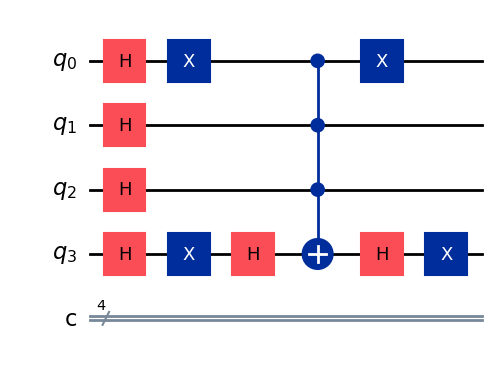

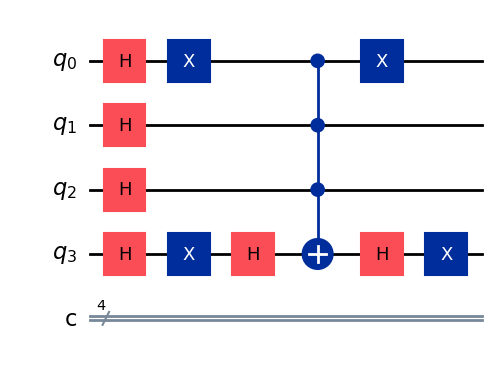

In [8]:
n=4
circuit=QuantumCircuit(n,n)
circuit.h(range(n))

for index,value in enumerate(reversed(binary_number)):
    if value=='0':
        circuit.x(index)

circuit.h(n-1)
circuit.mcx(list(range(n-1)), n-1)
circuit.h(n-1)

for index, value in enumerate(reversed(binary_number)):
    if value=='0':
        circuit.x(index)

circuit.draw(output='mpl')
        

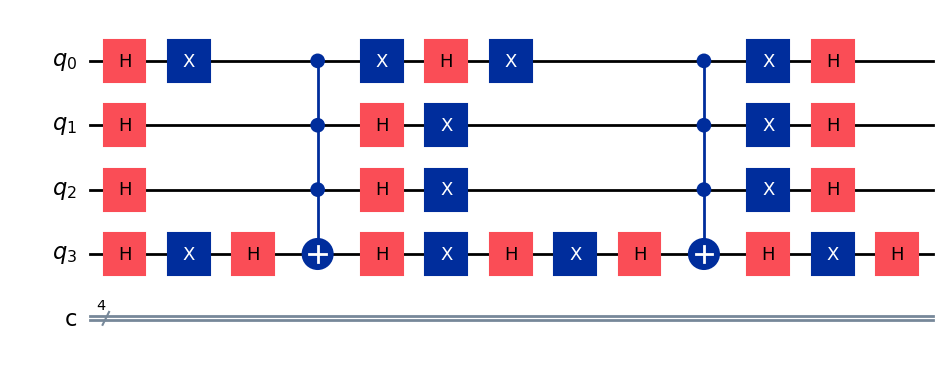

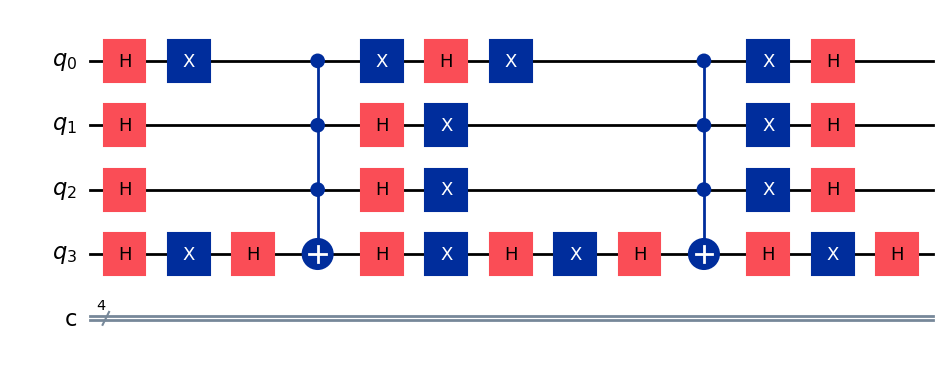

In [9]:
# Diffusion
circuit.h(range(n))
circuit.x(range(n))

circuit.h(n-1)
circuit.mcx(list(range(n-1)),n-1)
circuit.h(n-1)
circuit.x(range(n))
circuit.h(range(n))
circuit.draw(output='mpl')

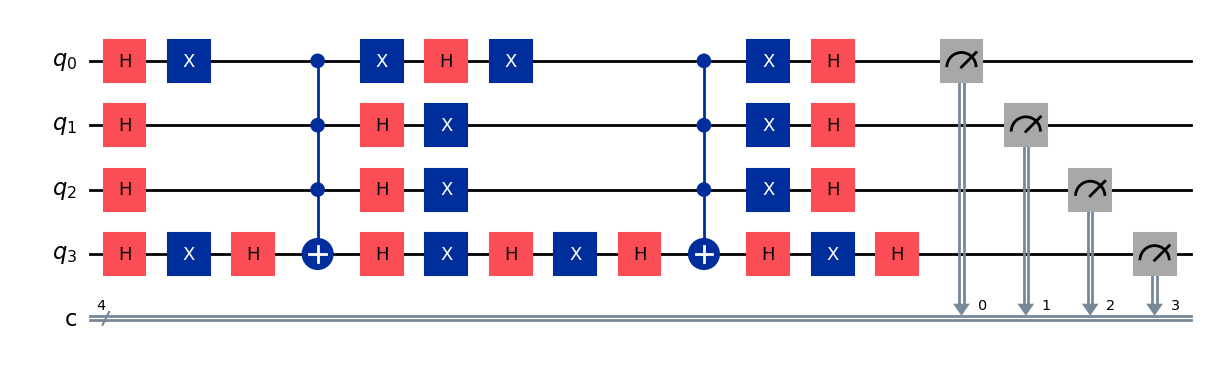

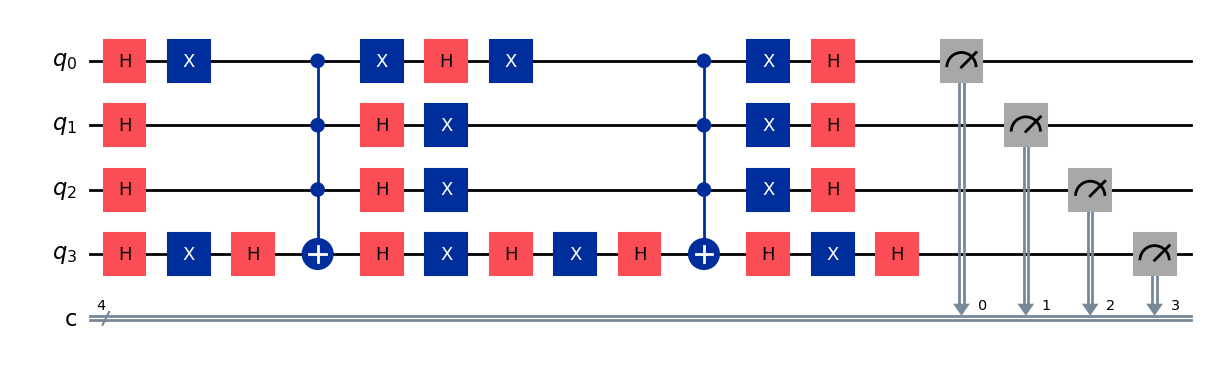

In [10]:
circuit.measure(range(n), range(n))
circuit.draw(output='mpl')

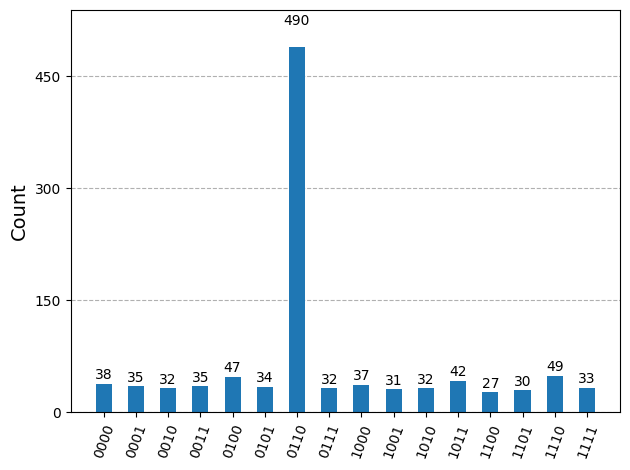

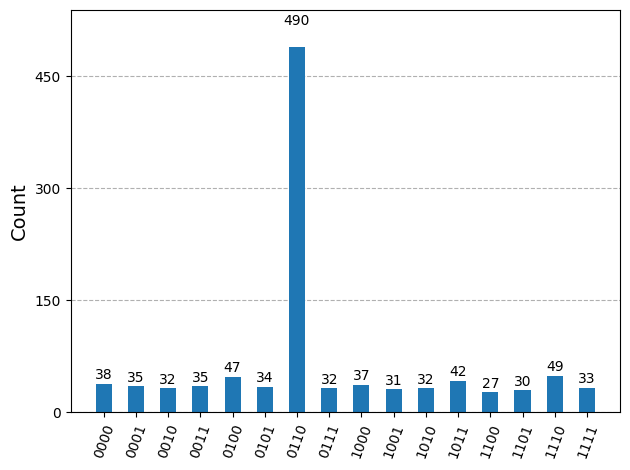

In [12]:
from qiskit_aer import Aer
simulator=Aer.get_backend('qasm_simulator')
circuit=transpile(circuit, simulator)
job=simulator.run(circuit,shots=1024)
result=job.result()
count=result.get_counts()
plot_histogram(count)